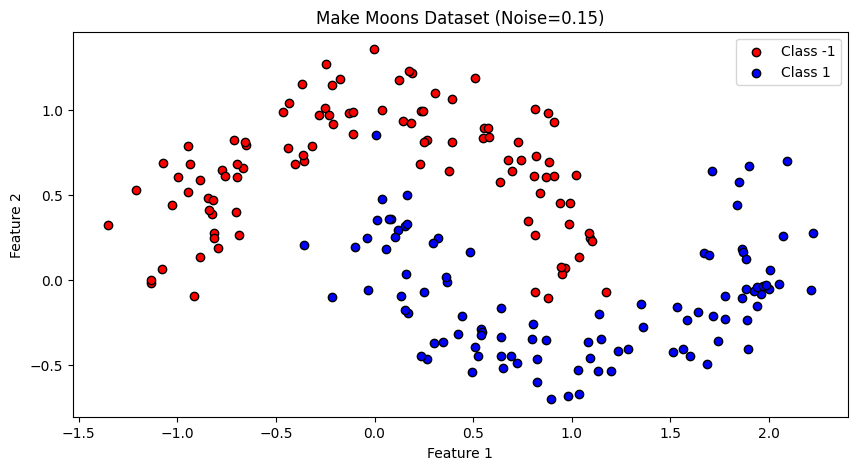

Dataset:
Total samples: 200
Class -1: 100
Class +1: 100
Success status : False
Optimization message : Positive directional derivative for linesearch
Number of constraint violations : 139


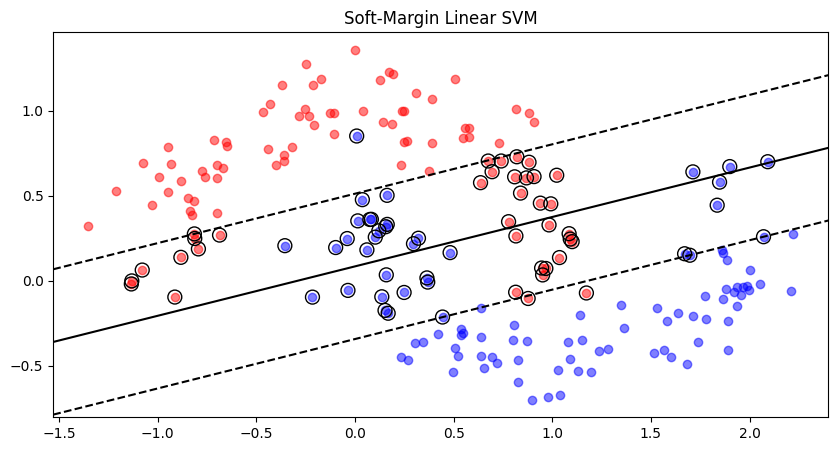

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from scipy.optimize import minimize

np.random.seed(42)

X,y = make_moons(n_samples=200,noise=0.15,random_state=42)
y_svm = np.where(y == 0,-1,1)

plt.figure(figsize=(10,5))
plt.scatter(X[y_svm == -1,0], X[y_svm == -1,1],color='red',label='Class -1',edgecolors='k')
plt.scatter(X[y_svm == 1,0],X[y_svm == 1,1],color='blue',label='Class 1',edgecolors='k')
plt.title("Make Moons Dataset (Noise=0.15)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

print("Dataset:")
print("Total samples:", len(X))
print("Class -1:",np.sum(y_svm == -1))
print("Class +1:",np.sum(y_svm == 1))

def objective(params):
    w = params[:2]
    return 0.5*np.dot(w,w)

def constraint_func(params,x_i,y_i):
    w = params[:2]
    b = params[2]
    return y_i*(np.dot(w,x_i)+b) - 1

constraints = []
for i in range(len(X)):
    constraints.append({'type':'ineq','fun':constraint_func,'args':(X[i], y_svm[i])})

initial_guess = np.random.randn(3)
result = minimize(objective,initial_guess,constraints=constraints,method='SLSQP')
final_params = result.x

violations = 0
for i in range(len(X)):
    if constraint_func(final_params,X[i],y_svm[i]) < -1e-6:
        violations += 1


print(f"Success status : {result.success}")
print(f"Optimization message : {result.message}")
print(f"Number of constraint violations : {violations}")

soft_svm = SVC(kernel='linear',C=1.0)
soft_svm.fit(X,y_svm)

plt.figure(figsize=(10,5))
plt.scatter(X[y_svm == -1,0],X[y_svm == -1,1],color='red',alpha=0.5)
plt.scatter(X[y_svm == 1,0],X[y_svm == 1,1],color='blue',alpha=0.5)

ax = plt.gca()
xlim,ylim = ax.get_xlim(),ax.get_ylim()

xx = np.linspace(xlim[0],xlim[1],30)
yy = np.linspace(ylim[0],ylim[1],30)
YY,XX = np.meshgrid(yy,xx)

xy = np.vstack([XX.ravel(),YY.ravel()]).T
Z = soft_svm.decision_function(xy).reshape(XX.shape)

ax.contour(XX,YY,Z,colors='k',levels=[-1,0,1],linestyles=['--','-','--'])

ax.scatter(soft_svm.support_vectors_[:, 0],soft_svm.support_vectors_[:, 1],s=100,facecolors='none',edgecolors='black')
plt.title("Soft-Margin Linear SVM")
plt.show()

## Step 1: Visual Verification of Non-Linear Separability

The dataset consists of two interleaving crescent-shaped clusters.  
From the visualization, it is evident that no straight line (i.e., no affine function $w^T x + b$) can separate the two classes without misclassification.

Hence, the dataset is **not linearly separable**.

---

## Step 2: Hard-Margin SVM and Infeasibility

We solve the hard-margin SVM problem:

$$
\min \frac{1}{2} \|w\|^2 \quad \text{s.t.} \quad y_i (w^T x_i + b) \geq 1 \ \forall i
$$

This defines a **feasible region** consisting of all $(w, b)$ that correctly classify every point with margin ≥ 1.

### Observations:
- The optimizer fails to converge to a feasible solution.
- After optimization, a large number of constraints are still violated.


Hence, the hard-margin SVM problem is **infeasible** for this dataset.

---

## Step 3: Soft-Margin SVM

To handle non-separable data, the soft-margin SVM introduces slack variables $\xi_i$:

$$
\min \frac{1}{2} \|w\|^2 + C \sum_i \xi_i
$$

$$
\text{s.t.} \quad y_i(w^T x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0
$$

This allows some violations of the margin constraints.

### Observations:
- The model successfully finds a separating hyperplane.
- Some points lie inside the margin or are misclassified.
- Support vectors define the decision boundary.

---

## Step 4: Comparison

### Hard-Margin SVM:
- Requires perfect separability  
- Feasible region is empty  
- Optimization problem is infeasible  

### Soft-Margin SVM:
- Allows constraint violations via slack variables  
- Feasible region becomes non-empty  
- Successfully learns a classifier  

---

### Conclusion:
The soft-margin SVM succeeds because it relaxes strict constraints, making optimization possible even for non-linearly separable data.